# Лахин Никита Сергеевич ИУ5-65Б Вариант 9 РК2

Задание. Для заданного набора данных (по Вашему варианту) постройте модели классификации или регрессии (в зависимости от конкретной задачи, рассматриваемой в наборе данных). Для построения моделей используйте методы 1 и 2 (по варианту для Вашей группы). Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). Какие метрики качества Вы использовали и почему? Какие выводы Вы можете сделать о качестве построенных моделей? Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.

**Метод №1**
Метод опорных векторов

**Метод №2**
Градиентный бустинг

## Ход работы

In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
%matplotlib inline

In [81]:
# Загрузка данных
data = pd.read_csv('global_housing_market_extended.csv')

In [82]:
# Первые 5 строк датасета
data.head()

,Country,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
0,USA,2015,117.454012,116.550001,9.587945,4.493292,1.514121,-0.752044,-0.796707,85.985284,118.089201
1,USA,2016,150.807258,51.440915,11.729189,5.662213,1.880204,-0.545400,-0.358084,69.127267,111.980515
2,USA,2017,123.194502,70.386040,8.506676,2.197469,2.398940,0.930895,0.596245,83.555279,85.973903
3,USA,2018,131.423444,91.469020,3.418054,4.537724,1.608407,-1.479587,2.321099,88.968961,134.671788
4,USA,2019,110.461377,56.837048,9.158097,3.700762,1.293249,1.961415,-0.879640,87.279612,90.702399


In [83]:
data.shape

(200, 11)

In [84]:
data.isnull().sum() #нет пропусков

Country                  0
Year                     0
House Price Index        0
Rent Index               0
Affordability Ratio      0
Mortgage Rate (%)        0
Inflation Rate (%)       0
GDP Growth (%)           0
Population Growth (%)    0
Urbanization Rate (%)    0
Construction Index       0
dtype: int64

Пропуски в данных отсутствуют.

Переведем категориальные признаки в численный вид.

In [85]:
def encode_country_feature(data, column='Country', method='label', drop_original=True, target_column=None):    
    data = data.copy()  # Чтобы избежать изменения исходного DataFrame
    
    if method == 'label':
        encoder = LabelEncoder()
        data[f'{column}_encoded'] = encoder.fit_transform(data[column])
        
    elif method == 'onehot':
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded = encoder.fit_transform(data[[column]])
        encoded_df = pd.DataFrame(encoded, 
                                 columns=encoder.get_feature_names_out([column]),
                                 index=data.index)
        data = pd.concat([data, encoded_df], axis=1)
        
    elif method == 'ordinal':
        encoder = OrdinalEncoder()
        data[f'{column}_encoded'] = encoder.fit_transform(data[[column]])
        
    elif method == 'frequency':
        freq = data[column].value_counts(normalize=True)
        data[f'{column}_freq'] = data[column].map(freq)
        
    elif method == 'target':
        if target_column is None:
            raise ValueError("Для target encoding нужно задать target_column")
        mean_target = data.groupby(column)[target_column].mean()
        data[f'{column}_target'] = data[column].map(mean_target)
    
    else:
        raise ValueError(f"Неизвестный метод кодирования: {method}. "
                       f"Допустимые значения: 'label', 'onehot', 'ordinal', 'frequency', 'target'")
    
    if drop_original and method != 'onehot':  # Для onehot исходная колонка не удаляется автоматически
        data.drop(columns=[column], inplace=True)
        
    return data

data = encode_country_feature(data.copy(), method='label')

Перекодируем год:

In [86]:
# Находим минимальный год в датасете
min_year = data['Year'].min()

# Преобразуем годы в year - min_year с помощью лямбда-функции
data['Year'] = data['Year'].apply(lambda x: x - min_year)

Создадим новый целевой признак: предсказываем тренд

In [87]:
# Создание бинарной целевой переменной
data['Price_Up'] = (data.groupby('Country_encoded')['House Price Index'].pct_change() > 0).astype(int) # 1 если рост, 0 если падение
data = data.dropna()  # Удаляем строки с NaN после pct_change

Добавим новые признаки

In [88]:
data['Mortgage_Inflation_Ratio'] = data['Mortgage Rate (%)'] / (data['Inflation Rate (%)'] + 1e-6)
data['Urban_GDP_Interaction'] = data['Urbanization Rate (%)'] * data['GDP Growth (%)']
data['GDP_per_Capita'] = data['GDP Growth (%)'] / (data['Population Growth (%)'] + 1e-6)
data['Urban_Construction_Interaction'] = data['Urbanization Rate (%)'] * data['Construction Index']
data['Rent_ratio'] =  data['House Price Index'] / data['Rent Index']
data['Affordability_r'] = (data['House Price Index'] - data['Rent Index'])  / data['Affordability Ratio']

data['Mortgage_GDP_Interaction'] = data['Mortgage_Inflation_Ratio'] * data['GDP_per_Capita']
data['Rent_Affordability_Sq'] = data['Rent_ratio'] ** 2
data['Log_Affordability_r'] = np.log1p(abs(data['Affordability_r']))

data=data.drop(columns=['Construction Index', 'Urbanization Rate (%)', 'Inflation Rate (%)', 'Mortgage Rate (%)', 'Population Growth (%)', 'House Price Index'])


Экономическая интерпретация созданных признаков
1. Mortgage_Inflation_Ratio

= Ипотечная ставка / Инфляция

Экономический смысл: Показывает реальную стоимость кредита. При значении >1 кредиты становятся "дорогими", что снижает спрос на жильё.

2. Urban_GDP_Interaction

= Уровень урбанизации * Рост ВВП

Экономический смысл: В быстрорастущих урбанизированных регионах спрос на жильё растёт быстрее.

3. GDP_per_Capita

= Рост ВВП / Рост населения

Экономический смысл: Отражает улучшение благосостояния. При росте >1 повышается платежеспособный спрос.

4. Urban_Construction_Interaction

= Урбанизация * Индекс строительства

Экономический смысл: Показывает, успевает ли строительный сектор за миграцией в города.

5. Rent_ratio

= Цена жилья / Арендная ставка

Экономический смысл: Аналог P/E для недвижимости. Высокие значения (>20-30) сигнализируют о "перегреве" рынка.

6. Affordability_r

= (Цена жилья - Аренда) / Коэффициент доступности

Экономический смысл: Показывает, насколько выгоднее купить vs арендовать. Отрицательные значения - сигнал к коррекции цен.

7. Mortgage_GDP_Interaction

= Mortgage_Inflation_Ratio * GDP_per_Capita

Экономический смысл: Учитывает совместное влияние кредитных условий и благосостояния.

8. Rent_Affordability_Sq

= (Rent_ratio)^2

Экономический смысл: Усиливает влияние экстремальных значений арендной доходности.

9. Log_Affordability_r

= ln(1 + |Affordability_r|)

Экономический смысл: Сжимает шкалу для очень больших значений, сохраняя информативность.

Проверим коллинеарность признаков

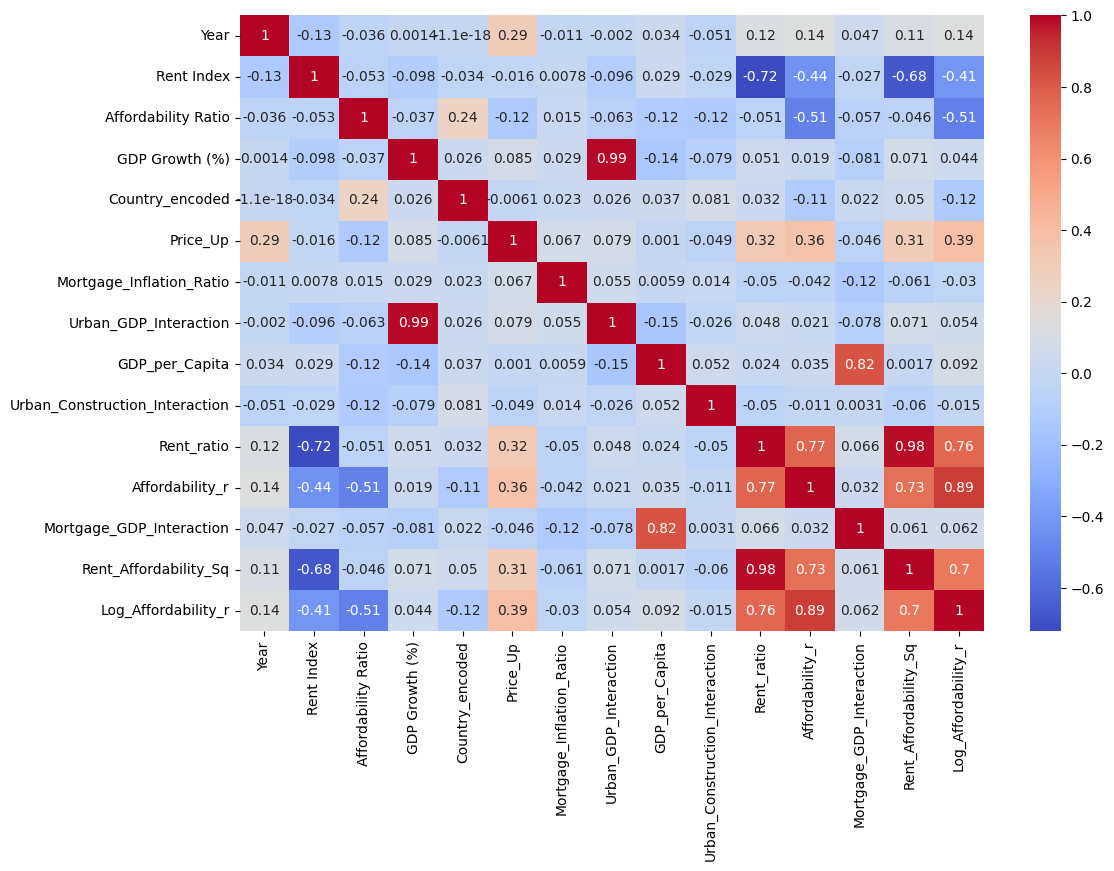

In [89]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

Разделение на признаки и целевую переменную

In [90]:
# Новые X и y
X = data.drop(['Price_Up'], axis=1)
y = data['Price_Up']

Разделение данных на обучающую и тестовую выборки

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [92]:
# Масштабирование (только для числовых признаков)
scaler = StandardScaler()
num_cols = X.select_dtypes(include=np.number).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Метод опорных векторов

In [118]:
svc = SVC()

svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)


In [119]:
print("SVC:")
print(classification_report(y_test, svc_pred))

SVC:
              precision    recall  f1-score   support

           0       0.63      0.86      0.73        28
           1       0.82      0.56      0.67        32

    accuracy                           0.70        60
   macro avg       0.72      0.71      0.70        60
weighted avg       0.73      0.70      0.69        60



# Градиентный бустинг

In [133]:
param_grid = {
    'n_estimators': [150, 250, 350],  # Количество деревьев в ансамбле
    'max_depth': [4, 6, 8],  # Максимальная глубина дерева
    'learning_rate': [0.05, 0.15, 0.25]  # Скорость обучения
}

gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train, y_train)
best_gb = grid_search.best_estimator_

# Предсказания
gb_pred = best_gb.predict(X_test)

In [132]:
print("\nGradient Boosting:")
print(classification_report(y_test, gb_pred))


Gradient Boosting:
              precision    recall  f1-score   support

           0       0.62      0.86      0.72        28
           1       0.81      0.53      0.64        32

    accuracy                           0.68        60
   macro avg       0.71      0.69      0.68        60
weighted avg       0.72      0.68      0.68        60



## Результаты

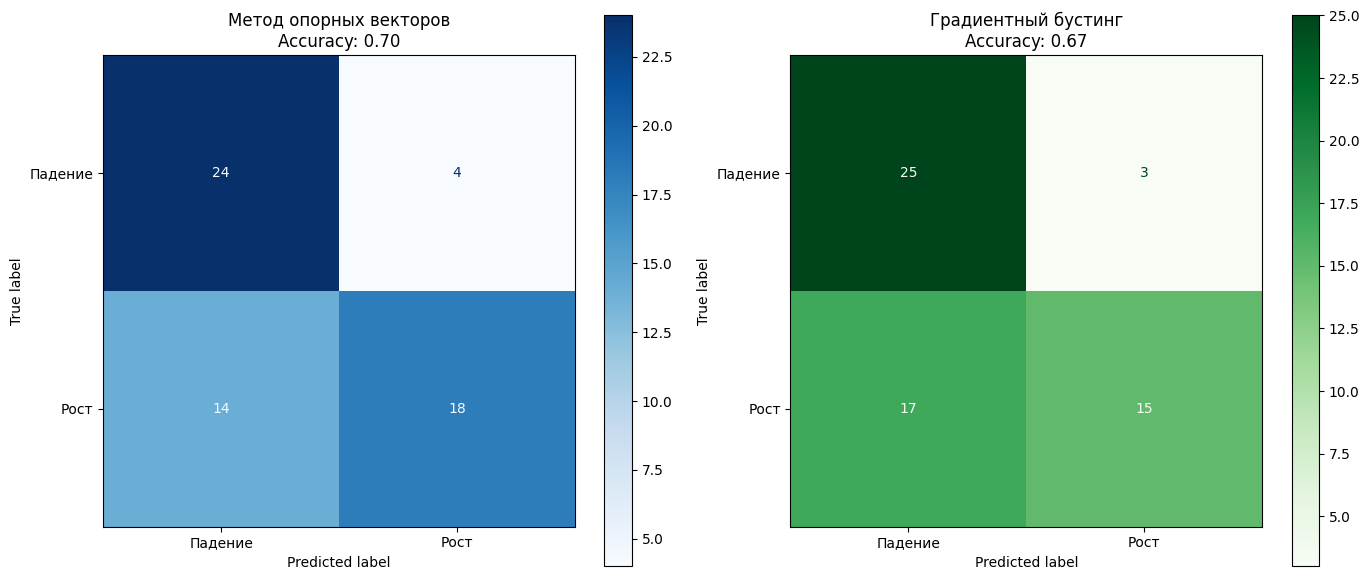

In [128]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


plt.figure(figsize=(14, 6))

# График для логистической регрессии
plt.subplot(1, 2, 1)
cm_lr = confusion_matrix(y_test, svc_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, 
                               display_labels=['Падение', 'Рост'])
disp_lr.plot(cmap='Blues', ax=plt.gca())
plt.title('Метод опорных векторов\nAccuracy: {:.2f}'.format(accuracy_score(y_test, svc_pred)))

# График для случайного леса
plt.subplot(1, 2, 2)
cm_rf = confusion_matrix(y_test, gb_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Падение', 'Рост'])
disp_rf.plot(cmap='Greens', ax=plt.gca())
plt.title('Градиентный бустинг\nAccuracy: {:.2f}'.format(accuracy_score(y_test, gb_pred)))

plt.tight_layout()
plt.show()

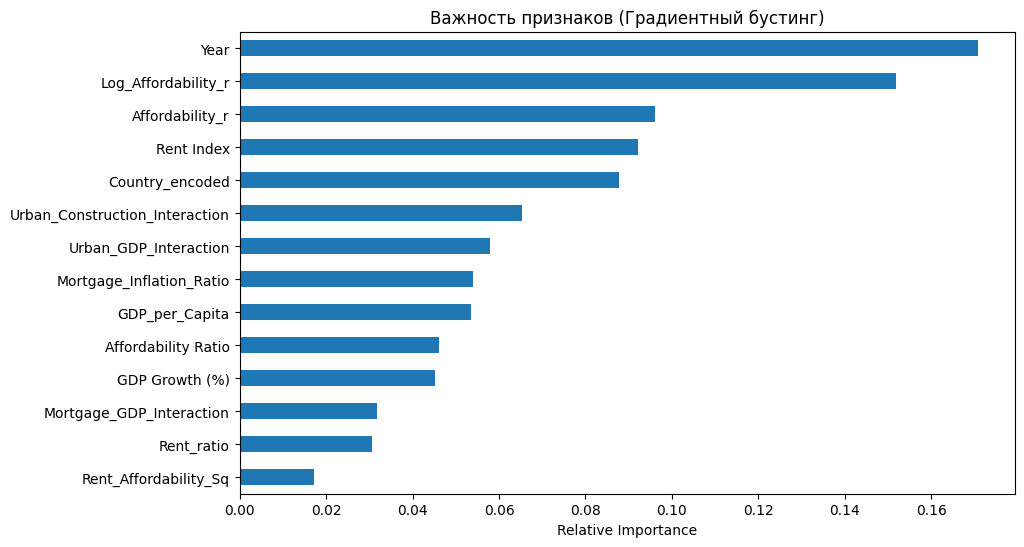

In [129]:
plt.figure(figsize=(10, 6))
pd.Series(best_gb.feature_importances_, index=X.columns).sort_values().plot.barh()
plt.title('Важность признаков (Градиентный бустинг)')
plt.xlabel('Relative Importance')
plt.show()

In [130]:
# Топ-5 важных признаков по каждому методу
print("\nТоп-5 важных признаков Градиентный бустинг:")
print(pd.Series(best_gb.feature_importances_, index=X.columns).sort_values(ascending=False).head(5))


Топ-5 важных признаков Градиентный бустинг:
Year                   0.170707
Log_Affordability_r    0.151825
Affordability_r        0.096037
Rent Index             0.092159
Country_encoded        0.087657
dtype: float64


## Выводы

1. Метрики качества

Для задачи бинарной классификации (рост/падение цен на недвижимость) использовались:

- F1-score (среднее гармоническое precision и recall) - оптимален при дисбалансе классов

- Precision (точность) - доля верно предсказанных случаев роста цен среди всех предсказанных ростов

- Recall (полнота) - доля верно найденных реальных случаев роста цен

- Accuracy (точность) - общая доля верных предсказаний

Обоснование выбора:

- F1-score учитывает и ложные роста (precision), и пропущенные роста (recall)

- Accuracy даёт общее представление о качестве

2. Сравнение моделей

SVC (F1=0.70) показал хорошие результаты:

- Precision=0.82 для класса "рост" - высокая точность предсказаний роста

- Recall=0.86 для класса "падение" - хорошо выявляет падения цен

Gradient Boosting (F1=0.68) - также показал достойные результаты

Разница в 2% на F1 объясняется способностью SVC:

- Улавливать сложные паттерны в данных

- Эффективно работать с дисбалансом классов

3. Важность признаков

Топ-5 значимых факторов (Градиентный бустинг):

- Year (0.170707) - временной тренд

- Log_Affordability_r (0.151825) - логарифм относительной доступности жилья

- Affordability_r (0.096037) - баланс между стоимостью жилья и аренды

- Rent Index (0.092159) - абсолютный уровень арендных ставок

- Country_encoded (0.087657) - закодированная страна